# Fish Price Series Exploration — 1500–1800

Goal: identify the best panel of Cod and Herring price series from `Big_DF` / `Big_DF_H`,
focusing on coverage within the **1500–1800** window.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA = '../data/'
YEAR_MIN, YEAR_MAX = 1500, 1800

df  = pd.read_csv(DATA + 'Big_DF.csv',   encoding='latin1')
dfh = pd.read_csv(DATA + 'Big_DF_H.csv', encoding='latin1')

df  = df.rename(columns={df.columns[0]: 'row_idx'})
dfh = dfh.rename(columns={dfh.columns[0]: 'row_idx'})
dfh = dfh[dfh['Series.ID'] != 'Series.ID'].reset_index(drop=True)

# Restrict to 1500–1800
df = df[(df['Year'].astype(float) >= YEAR_MIN) & (df['Year'].astype(float) <= YEAR_MAX)].copy()
df['Year'] = df['Year'].astype(int)

print(f'Big_DF:   {df.shape}  | Year range: {df["Year"].min()}–{df["Year"].max()}')
print(f'Big_DF_H: {dfh.shape}')
print(dfh.columns.tolist())

Big_DF:   (301, 463)  | Year range: 1500–1800
Big_DF_H: (461, 17)
['row_idx', 'Series.ID', 'Report.Header.01', 'Series.Grouping.1', 'Country', 'City', 'Unit', 'Unit.Amount', 'Weight.KG', 'Name', 'Product.Category.01', 'Product.Category.02', 'Currency', 'FX.to.apply', 'Source', 'Price.Level', 'File.Name']


## 1. Extract Cod and Herring series

In [22]:
cod_ids     = dfh[dfh['Product.Category.01'] == 'Cod']['Series.ID'].tolist()
herring_ids = dfh[dfh['Product.Category.01'] == 'Herring']['Series.ID'].tolist()

cod_ids     = [c for c in cod_ids     if c in df.columns]
herring_ids = [c for c in herring_ids if c in df.columns]

# Drop series with zero observations in the 1500–1800 window
cod_ids     = [c for c in cod_ids     if df[c].notna().any()]
herring_ids = [c for c in herring_ids if df[c].notna().any()]

print(f'Cod series with data 1500–1800:     {len(cod_ids)}')
print(f'Herring series with data 1500–1800: {len(herring_ids)}')

meta_cols = ['Series.ID','Report.Header.01','Country','City','Unit','Source']
meta_cod     = dfh[dfh['Series.ID'].isin(cod_ids)][meta_cols]
meta_herring = dfh[dfh['Series.ID'].isin(herring_ids)][meta_cols]

print('\nCod metadata:')
display(meta_cod)
print('\nHerring metadata:')
display(meta_herring)

Cod series with data 1500–1800:     52
Herring series with data 1500–1800: 26

Cod metadata:


,Series.ID,Report.Header.01,Country,City,Unit,Source
0,A1Cod001,cod,France,Paris,NaN,Allaire
1,A1Cod002,entire cod,France,Paris,NaN,Allaire
2,A1Cod003,fresh cod,France,Paris,Fish,Allaire
3,A1Cod004,big fresh cod (20 inches & more),France,Paris,NaN,Allaire
4,A1Cod005,fresh cod (16-18 inches),France,Paris,NaN,Allaire
5,A1Cod006,smaller fresh cod,France,Paris,NaN,Allaire
6,A1Cod007,piece of cod,France,Paris,NaN,Allaire
7,A1Cod008,dry cod (maybe Stockfish : dry non-salted),France,Paris,NaN,Allaire
8,A1Cod009,salted cod,France,Paris,Fish,Allaire
9,A1Cod010,salted cod (making 4 pieces),France,Paris,NaN,Allaire



Herring metadata:


,Series.ID,Report.Header.01,Country,City,Unit,Source
44,A1SS001,white (salted) herring (100),France,Paris,NaN,Allaire
45,A1SS002,marked white (salted) herring (100),France,Paris,NaN,Allaire
46,A1SS003,bloater herring (100),France,Paris,NaN,Allaire
47,A1SS004,fresh herring (100),France,Paris,Fish,Allaire
48,A1SS005,fresh herring (pound),France,Paris,NaN,Allaire
123,DanzigHerring001,Herring (Unit?),Poland,Gdansk,Beczka,Allen-Unger
150,GdanskHerring001,Gdansk Herring 01,Poland,Gdansk,Grams Ag/piece,Allen-Unger
164,NurembergHerring001,Nuremberg Herring,Germany,Nuremberg,Tonne,Bauernfeind
168,FeSpanHerr01,I. Precios de compra. (Purchase Price) (VII. 15),Spain,Barcelona,NaN,Feliu
169,FeSpanHerr02,II. Precios de tasa. (Rate Price) Check what ...,Spain,Barcelona,NaN,Feliu


## 2. Coverage statistics per series

In [29]:
def coverage_stats(series_ids, species_label):
    rows = []
    for sid in series_ids:
        s = df.set_index('Year')[sid].dropna()
        if len(s) == 0:
            continue
        years = s.index.astype(int).sort_values()
        gaps  = years.to_series().diff().dropna()
        rows.append({
            'Series.ID':     sid,
            'Species':       species_label,
            'n_obs':         len(years),
            'year_min':      int(years.min()),
            'year_max':      int(years.max()),
            'span':          int(years.max() - years.min() + 1),
            'n_gaps':        int((gaps > 1).sum()),
            'max_gap':       int(gaps.max()) if len(gaps) > 0 else 0,
            'total_gap_yrs': int((gaps[gaps > 1] - 1).sum()) if (gaps > 1).any() else 0,
            'density':       len(years) / (years.max() - years.min() + 1),
        })
    return pd.DataFrame(rows)

stats_cod     = coverage_stats(cod_ids,     'Cod')
stats_herring = coverage_stats(herring_ids, 'Herring')
stats_all     = pd.concat([stats_cod, stats_herring], ignore_index=True)

meta_all = dfh[dfh['Series.ID'].isin(cod_ids + herring_ids)][
    ['Series.ID','Report.Header.01','Country','City','Unit','Currency','Source']
]
stats_all = stats_all.merge(meta_all, on='Series.ID', how='left')

# Filter: keep only series with max_gap < 10 years and span > 100 years
stats_all = stats_all[(stats_all['max_gap'] < 20) & (stats_all['span'] > 100)].reset_index(drop=True)

print(f"Series remaining after max_gap < 10 & span > 100 filter: {len(stats_all)}")
display(stats_all.sort_values(['Species','density'], ascending=[True,False]))

Series remaining after max_gap < 10 & span > 100 filter: 22


,Series.ID,Species,n_obs,year_min,year_max,span,n_gaps,max_gap,total_gap_yrs,density,Report.Header.01,Country,City,Unit,Currency,Source
8,BergenStockfish001,Cod,101,1500,1600,101,0,1,0,1.000000,Bergen Stockfish,Norway,Bergen,Summer,NaN,Nedkvitne
5,LondonSaltedCod001,Cod,86,1659,1760,102,6,7,16,0.843137,NaN,England,London,NaN,Grams Ag,Allen-Unger
0,FeSpanCod001,Cod,168,1574,1798,225,23,8,57,0.746667,I. Compras de los conventos. (VII. 4),Spain,Barcelona,Barrel?,NaN,Feliu
1,FeSpanCod002,Cod,168,1574,1798,225,23,8,57,0.746667,II. Tasa municipal. (VII. 4),Spain,Barcelona,NaN,NaN,Feliu
6,MunichStockfish001old,Cod,74,1530,1637,108,16,10,34,0.685185,Munich Stockfish,Germany,Munich,NaN,NaN,Allen-Unger
7,MunichStockfish001,Cod,74,1530,1637,108,16,10,34,0.685185,Munich Stockfish,Germany,Munich,NaN,NaN,Allen-Unger
4,Dutch.Stockfish.Source.Units.002,Cod,108,1643,1800,158,20,10,50,0.683544,Dutch Stockfish,Netherlands,Amsterdam,NaN,Guilders,Allen-Unger
2,FeSpanCod003,Cod,87,1593,1773,181,26,15,94,0.480663,III. Propuesta de unification. (VII. 4),Spain,Barcelona,NaN,NaN,Feliu
3,FeSpanCodComp001,Cod,33,1571,1736,166,32,10,133,0.198795,I: Barcelona.,Spain,Barcelona,NaN,NaN,Feliu
21,AntwerpHerring001,Herring,101,1500,1600,101,0,1,0,1.000000,Herring,Belgium,Antwerp,Grams Ag/Each,Grams Ag,Allen-Unger


## 3. Score and select best series per location × species

In [30]:
def minmax(x):
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 0 else pd.Series(0.5, index=x.index)

s = stats_all.copy()
s['score'] = (
    0.35 * minmax(s['span']) +
    0.35 * minmax(s['density']) +
    0.20 * (1 - minmax(s['max_gap'])) +
    0.10 * minmax(s['n_obs'])
)

best = (
    s.sort_values('score', ascending=False)
     .groupby(['City', 'Species'], as_index=False)
     .first()
     .sort_values(['Species', 'score'], ascending=[True, False])
)

print('Best series per location × species (1500–1800):')
display(best[['Series.ID','Species','Country','City','year_min','year_max',
              'span','n_obs','max_gap','density','score','Report.Header.01']]
        .round(3))

Best series per location × species (1500–1800):


,Series.ID,Species,Country,City,year_min,year_max,span,n_obs,max_gap,density,score,Report.Header.01
3,FeSpanCod001,Cod,Spain,Barcelona,1574,1798,225,168,8,0.747,0.655,I. Compras de los conventos. (VII. 4)
4,BergenStockfish001,Cod,Norway,Bergen,1500,1600,101,101,1,1.000,0.588,Bergen Stockfish
0,Dutch.Stockfish.Source.Units.002,Cod,Netherlands,Amsterdam,1643,1800,158,108,10,0.684,0.450,Dutch Stockfish
6,LondonSaltedCod001,Cod,England,London,1659,1760,102,86,7,0.843,0.442,None
7,MunichStockfish001,Cod,Germany,Munich,1530,1637,108,74,10,0.685,0.342,Munich Stockfish
5,GdanskHerring001,Herring,Poland,Gdansk,1504,1792,289,211,13,0.730,0.728,Gdansk Herring 01
1,DutchHerring001.old,Herring,Netherlands,Amsterdam,1500,1795,296,190,13,0.642,0.691,The Dutch Price (Interpolated) [old]
2,AntwerpHerring001,Herring,Belgium,Antwerp,1500,1600,101,101,1,1.000,0.588,Herring
10,SwedenHerring002,Herring,Sweden,Stockholm,1600,1719,120,104,3,0.867,0.542,Herring (Stromming Stockholm)
8,MunichHerring001old,Herring,Germany,Munich,1524,1627,104,70,6,0.673,0.375,Munich Herring


## 4. Timeline plot of selected series

TypeError: 'NoneType' object is not subscriptable

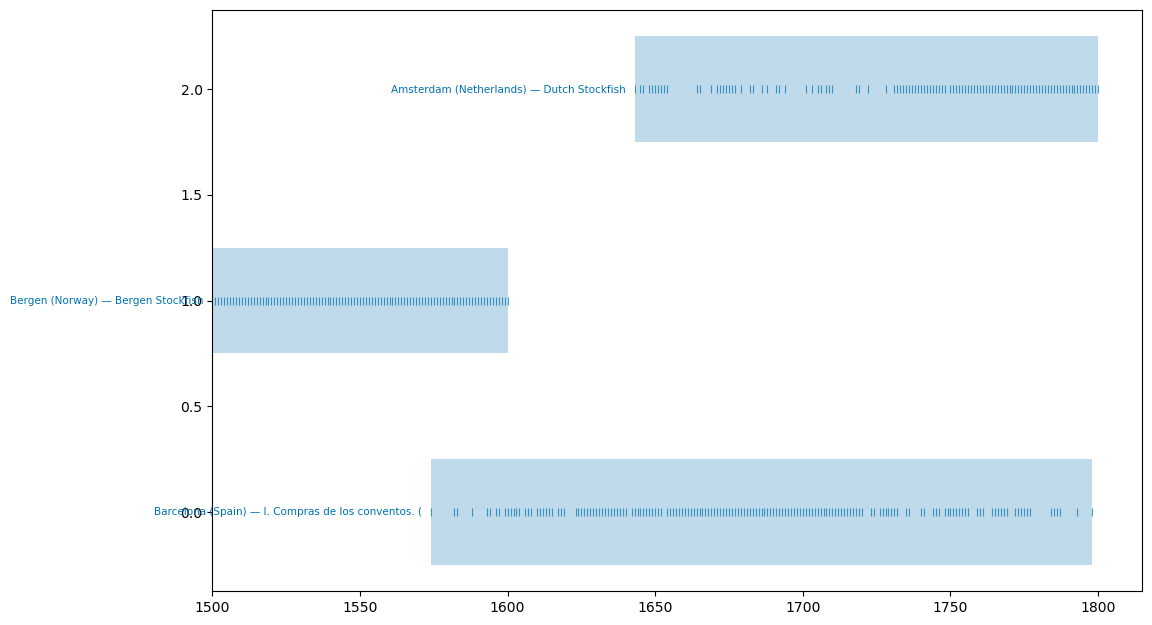

In [31]:
colors = {'Cod': '#0072B2', 'Herring': '#D55E00'}

fig, ax = plt.subplots(figsize=(12, 0.55 * len(best) + 1.5))

for i, row in best.reset_index(drop=True).iterrows():
    sid   = row['Series.ID']
    s     = df.set_index('Year')[sid].dropna()
    years = s.index.astype(int).sort_values()
    label = f"{row['City']} ({row['Country']}) — {row['Report.Header.01'][:30]}"
    c     = colors[row['Species']]
    ax.barh(i, years.max() - years.min(), left=years.min(),
            height=0.5, color=c, alpha=0.25)
    ax.scatter(years, [i]*len(years), marker='|', s=40, color=c, linewidths=0.8, alpha=0.7)
    ax.text(years.min() - 3, i, label, va='center', ha='right', fontsize=7.5, color=c)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=colors['Cod'], label='Cod'),
                   Patch(color=colors['Herring'], label='Herring')],
          loc='lower right', fontsize=9)

ax.set_yticks([])
ax.set_xlabel('Year')
ax.set_title('Best series per location × species: temporal coverage (1500–1800)')
ax.spines[['top','right','left']].set_visible(False)
ax.set_xlim(YEAR_MIN - 60, YEAR_MAX + 10)
ax.axvline(YEAR_MIN, color='grey', linestyle=':', linewidth=0.8)
ax.axvline(YEAR_MAX, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Gap distribution across all Cod and Herring series

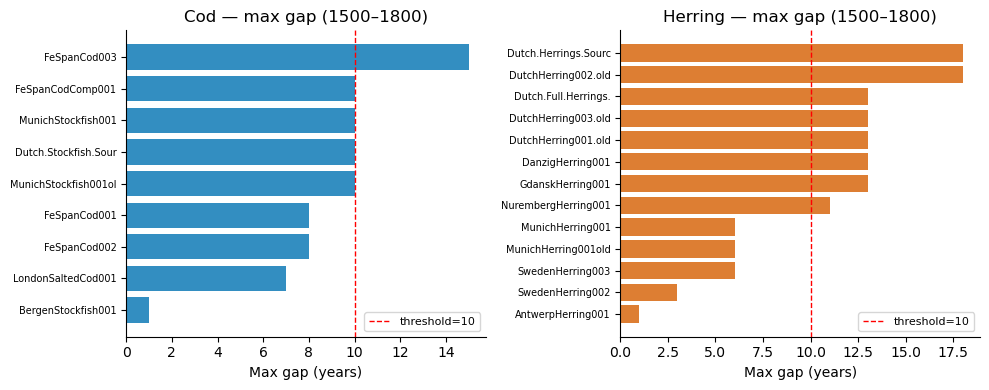

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, (species, grp) in zip(axes, stats_all.groupby('Species')):
    grp_sorted = grp.sort_values('max_gap')
    ax.barh(range(len(grp_sorted)), grp_sorted['max_gap'],
            color=colors[species], alpha=0.8)
    ax.set_yticks(range(len(grp_sorted)))
    ax.set_yticklabels(grp_sorted['Series.ID'].str[:20], fontsize=7)
    ax.axvline(10, color='red', linestyle='--', linewidth=1, label='threshold=10')
    ax.set_xlabel('Max gap (years)')
    ax.set_title(f'{species} — max gap (1500–1800)')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Price levels of selected series (raw, log)

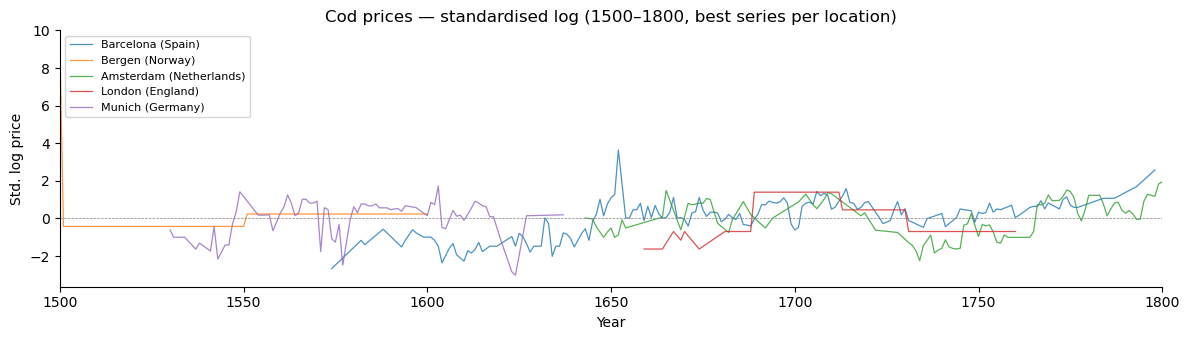

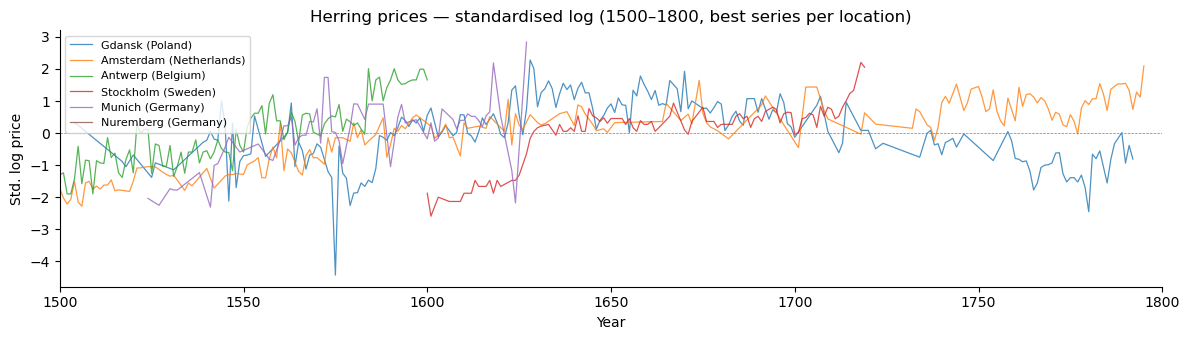

In [33]:
for species, grp in best.groupby('Species'):
    fig, ax = plt.subplots(figsize=(12, 3.5))
    for _, row in grp.iterrows():
        sid = row['Series.ID']
        s   = df.set_index('Year')[sid].dropna()
        ls  = np.log(s.astype(float))
        ls  = (ls - ls.mean()) / ls.std()
        lbl = f"{row['City']} ({row['Country']})"
        ax.plot(ls.index.astype(int), ls.values, linewidth=0.9, alpha=0.8, label=lbl)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlim(YEAR_MIN, YEAR_MAX)
    ax.set_title(f'{species} prices — standardised log (1500–1800, best series per location)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Std. log price')
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

## 7. Summary table: final recommended panel

In [34]:
final = best[['Series.ID','Species','Country','City',
              'year_min','year_max','span','n_obs','max_gap','total_gap_yrs','density','score']].copy()
final = final.sort_values(['Species','score'], ascending=[True,False]).round(3)
print('Recommended panel (1500–1800):')
display(final)

print(f'\nCod series:     {(final.Species=="Cod").sum()}')
print(f'Herring series: {(final.Species=="Herring").sum()}')
print(f'Locations with both species: {final.groupby("City")["Species"].nunique().eq(2).sum()}')

Recommended panel (1500–1800):


,Series.ID,Species,Country,City,year_min,year_max,span,n_obs,max_gap,total_gap_yrs,density,score
3,FeSpanCod001,Cod,Spain,Barcelona,1574,1798,225,168,8,57,0.747,0.655
4,BergenStockfish001,Cod,Norway,Bergen,1500,1600,101,101,1,0,1.000,0.588
0,Dutch.Stockfish.Source.Units.002,Cod,Netherlands,Amsterdam,1643,1800,158,108,10,50,0.684,0.450
6,LondonSaltedCod001,Cod,England,London,1659,1760,102,86,7,16,0.843,0.442
7,MunichStockfish001,Cod,Germany,Munich,1530,1637,108,74,10,34,0.685,0.342
5,GdanskHerring001,Herring,Poland,Gdansk,1504,1792,289,211,13,78,0.730,0.728
1,DutchHerring001.old,Herring,Netherlands,Amsterdam,1500,1795,296,190,13,106,0.642,0.691
2,AntwerpHerring001,Herring,Belgium,Antwerp,1500,1600,101,101,1,0,1.000,0.588
10,SwedenHerring002,Herring,Sweden,Stockholm,1600,1719,120,104,3,16,0.867,0.542
8,MunichHerring001old,Herring,Germany,Munich,1524,1627,104,70,6,34,0.673,0.375



Cod series:     5
Herring series: 6
Locations with both species: 2
